In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading
Loading the dataset and performing an initial exploration to understand its structure.

In [3]:
df = pd.read_csv('Financial Statements.csv')

In [4]:
print(df.shape)

(161, 23)


In [5]:
print(df.head())

   Year Company  Category  Market Cap(in B USD)   Revenue  Gross Profit  \
0  2022     AAPL       IT               2066.94  394328.0      170782.0   
1  2021     AAPL       IT               2913.28  365817.0      152836.0   
2  2020     AAPL       IT               2255.97  274515.0      104956.0   
3  2019     AAPL       IT               1304.76  260174.0       98392.0   
4  2018     AAPL       IT                748.54  265595.0      101839.0   

   Net Income  Earning Per Share    EBITDA  Share Holder Equity  ...  \
0     99803.0               6.11  130541.0              50672.0  ...   
1     94680.0               5.61  120233.0              63090.0  ...   
2     57411.0               3.28   77344.0              65339.0  ...   
3     55256.0               2.97   76477.0              90488.0  ...   
4     59531.0               2.98   81801.0             107147.0  ...   

   Current Ratio  Debt/Equity Ratio       ROE      ROA      ROI  \
0         0.8794             2.3695  196.9589  28

In [6]:
print(df.dtypes)

Year                                     int64
Company                                 object
Category                                object
Market Cap(in B USD)                   float64
Revenue                                float64
Gross Profit                           float64
Net Income                             float64
Earning Per Share                      float64
EBITDA                                 float64
Share Holder Equity                    float64
Cash Flow from Operating               float64
Cash Flow from Investing               float64
Cash Flow from Financial Activities    float64
Current Ratio                          float64
Debt/Equity Ratio                      float64
ROE                                    float64
ROA                                    float64
ROI                                    float64
Net Profit Margin                      float64
Free Cash Flow per Share               float64
Return on Tangible Equity              float64
Number of Emp

In [7]:
print(df.isnull().sum())

Year                                   0
Company                                0
Category                               0
Market Cap(in B USD)                   1
Revenue                                0
Gross Profit                           0
Net Income                             0
Earning Per Share                      0
EBITDA                                 0
Share Holder Equity                    0
Cash Flow from Operating               0
Cash Flow from Investing               0
Cash Flow from Financial Activities    0
Current Ratio                          0
Debt/Equity Ratio                      0
ROE                                    0
ROA                                    0
ROI                                    0
Net Profit Margin                      0
Free Cash Flow per Share               0
Return on Tangible Equity              0
Number of Employees                    0
Inflation Rate(in US)                  0
dtype: int64


In [8]:
print(df.describe())

              Year  Market Cap(in B USD)        Revenue   Gross Profit  \
count   161.000000            160.000000     161.000000     161.000000   
mean   2015.608696            337.604312   75862.600758   37383.463124   
std       4.049960            541.102812   90786.895983   41669.093697   
min    2009.000000              0.040000    3326.445000    1174.269000   
25%    2012.000000             41.155000   22820.400000   10396.000000   
50%    2016.000000            113.140000   45992.040000   19561.000000   
75%    2019.000000            357.107500   77849.000000   47722.000000   
max    2023.000000           2913.280000  513983.000000  225152.000000   

         Net Income  Earning Per Share         EBITDA  Share Holder Equity  \
count    161.000000         161.000000     161.000000           161.000000   
mean   12276.607076           0.982886   20174.023974         57178.005273   
std    19417.421119           8.874504   26342.029803         54098.208311   
min   -12244.000000  

In [9]:
print(df.columns.tolist())

['Year', 'Company ', 'Category', 'Market Cap(in B USD)', 'Revenue', 'Gross Profit', 'Net Income', 'Earning Per Share', 'EBITDA', 'Share Holder Equity', 'Cash Flow from Operating', 'Cash Flow from Investing', 'Cash Flow from Financial Activities', 'Current Ratio', 'Debt/Equity Ratio', 'ROE', 'ROA', 'ROI', 'Net Profit Margin', 'Free Cash Flow per Share', 'Return on Tangible Equity', 'Number of Employees', 'Inflation Rate(in US)']


## 2. Data Cleaning
Fixing column names and standardizing categorical values for consistency.

In [10]:
df.rename(columns={'Company ': 'Company'}, inplace=True)

In [11]:
print(df['Category'].unique())
print(df['Company'].unique())
print(df.groupby('Category')['Company'].unique())

['IT' 'FinTech' 'Bank' 'Manufacturing' 'Finance' 'FOOD' 'BANK' 'ELEC'
 'LOGI']
['AAPL' 'MSFT' 'GOOG' 'PYPL' 'AIG' 'PCG' 'SHLDQ' 'MCD' 'BCS' 'NVDA' 'INTC'
 'AMZN']
Category
BANK                          [BCS]
Bank                          [AIG]
ELEC                   [NVDA, INTC]
FOOD                          [MCD]
FinTech                      [PYPL]
Finance                     [SHLDQ]
IT               [AAPL, MSFT, GOOG]
LOGI                         [AMZN]
Manufacturing                 [PCG]
Name: Company, dtype: object


In [12]:
df['Category'] = df['Category'].str.strip().str.upper()

In [13]:
print(df['Category'].unique())
print(df.shape)
print(df.groupby('Category')['Company'].unique())

['IT' 'FINTECH' 'BANK' 'MANUFACTURING' 'FINANCE' 'FOOD' 'ELEC' 'LOGI']
(161, 23)
Category
BANK                     [AIG, BCS]
ELEC                   [NVDA, INTC]
FINANCE                     [SHLDQ]
FINTECH                      [PYPL]
FOOD                          [MCD]
IT               [AAPL, MSFT, GOOG]
LOGI                         [AMZN]
MANUFACTURING                 [PCG]
Name: Company, dtype: object


## 3. Univariate Analysis
Analyzing individual variables to understand their distribution and key statistics.

### 3.1 Distribution of Net Profit Margin
Visualizing how profit margins are distributed across all records.

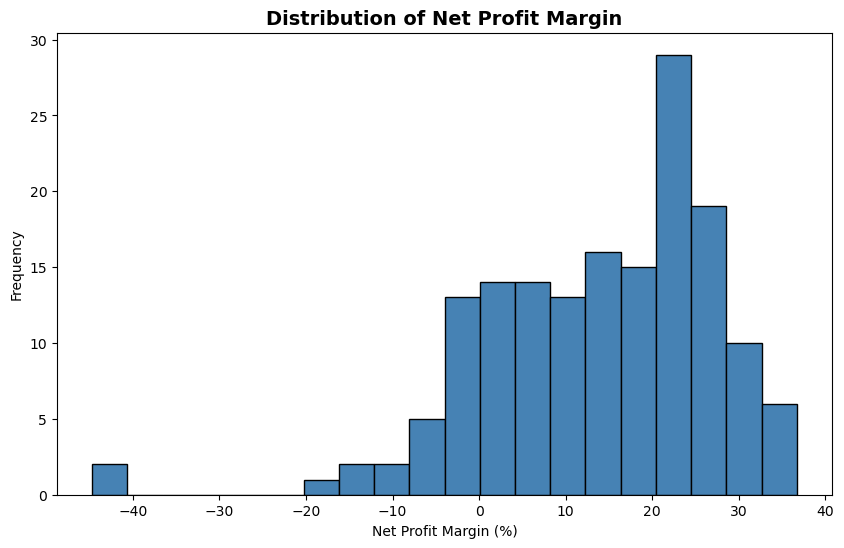

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(df['Net Profit Margin'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Net Profit Margin', fontsize=14, fontweight='bold')
plt.xlabel('Net Profit Margin (%)')
plt.ylabel('Frequency')
plt.show()

#### Findings
Most companies have margins between 0% and 30%. The left tail (down to -44%) is driven by SHLDQ and PCG during their crisis years. The median is more reliable than the mean due to these outliers.

### 3.2 Net Profit Margin by Sector
Comparing margin distributions across sectors using a boxplot.

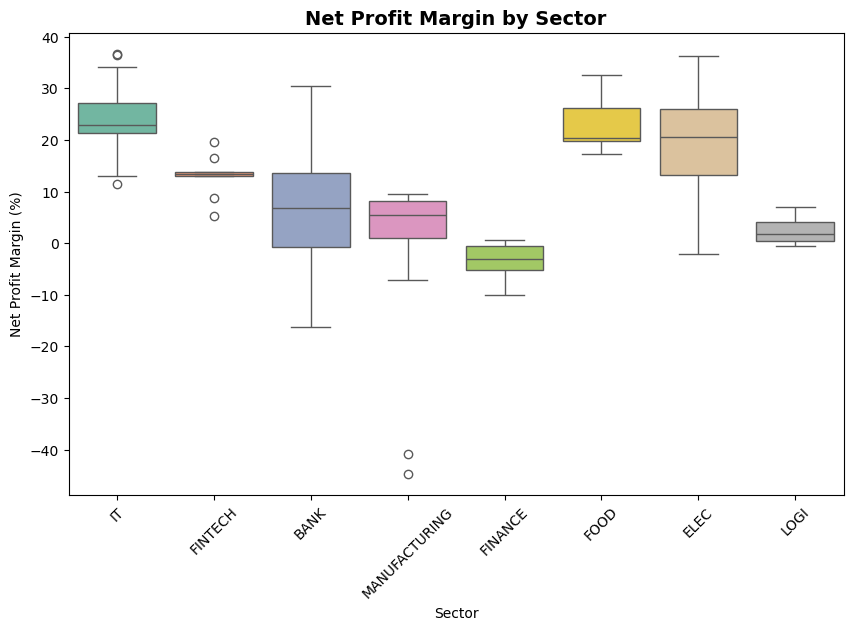

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Category', y='Net Profit Margin', 
            hue='Category', palette='Set2', legend=False)
plt.title('Net Profit Margin by Sector', fontsize=14, fontweight='bold')
plt.xlabel('Sector')
plt.ylabel('Net Profit Margin (%)')
plt.xticks(rotation=45)
plt.show()

#### Findings
IT, FOOD and ELEC are the most profitable sectors. FINANCE and MANUFACTURING show negative margins in several years. LOGI (AMZN) has surprisingly low margins despite its size, it prioritizes growth over profit.

### 3.3 Distribution of ROE
Understanding how Return on Equity is distributed, including mean vs median.

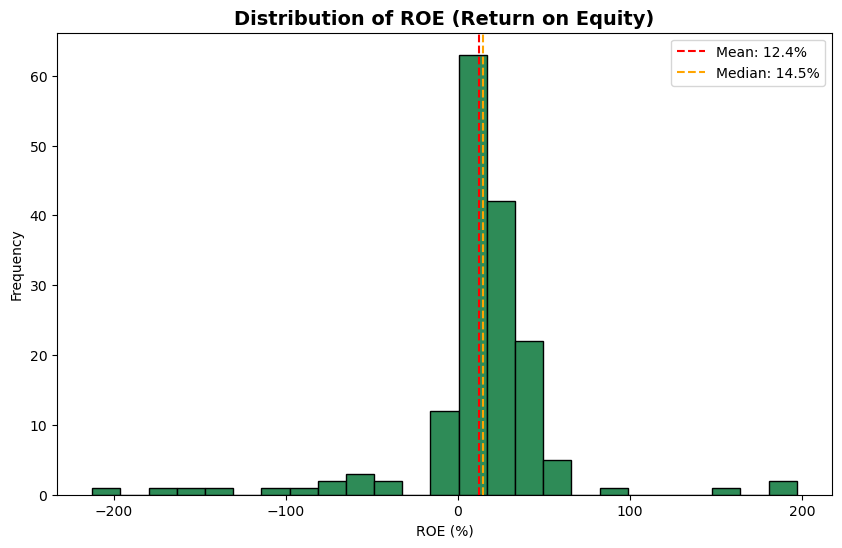

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(df['ROE'], bins=25, color='seagreen', edgecolor='black')
plt.title('Distribution of ROE (Return on Equity)', fontsize=14, fontweight='bold')
plt.xlabel('ROE (%)')
plt.ylabel('Frequency')
plt.axvline(df['ROE'].mean(), color='red', linestyle='--', label=f"Mean: {df['ROE'].mean():.1f}%")
plt.axvline(df['ROE'].median(), color='orange', linestyle='--', label=f"Median: {df['ROE'].median():.1f}%")
plt.legend()
plt.show()

#### Findings
Most values are concentrated between 0% and 50%. The mean (12.4%) is below the median (14.5%) due to extreme outliers on both sides. The median is the better central measure here.

### 3.4 Distribution of Debt/Equity Ratio
Identifying companies above the risk threshold of 2.0.

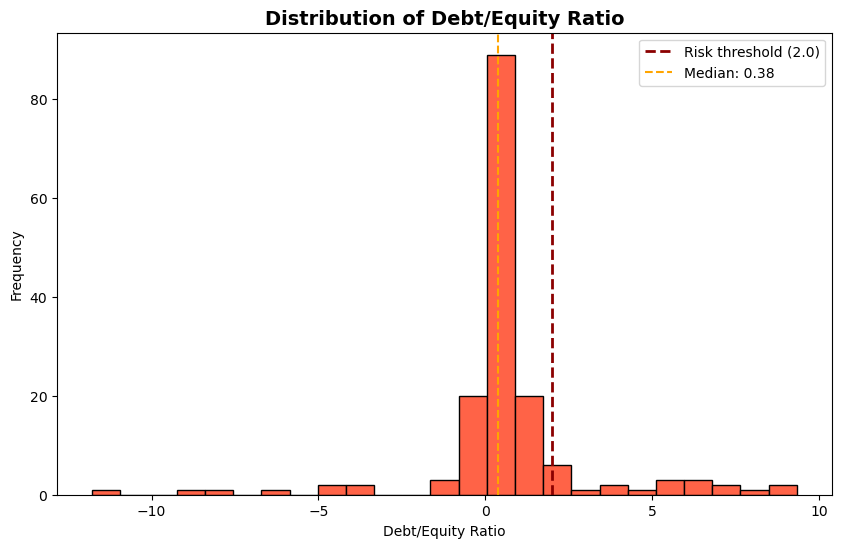

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(df['Debt/Equity Ratio'], bins=25, color='tomato', edgecolor='black')
plt.title('Distribution of Debt/Equity Ratio', fontsize=14, fontweight='bold')
plt.xlabel('Debt/Equity Ratio')
plt.ylabel('Frequency')
plt.axvline(2, color='darkred', linestyle='--', linewidth=2, label='Risk threshold (2.0)')
plt.axvline(df['Debt/Equity Ratio'].median(), color='orange', linestyle='--', label=f"Median: {df['Debt/Equity Ratio'].median():.2f}")
plt.legend()
plt.show()

#### Findings
Most companies are well below the risk threshold of 2.0 (median: 0.38). Negative values indicate companies with negative shareholders equity, which is even more concerning than high debt.

### 3.5 Average Revenue by Company
Ranking companies by average revenue over the full period.

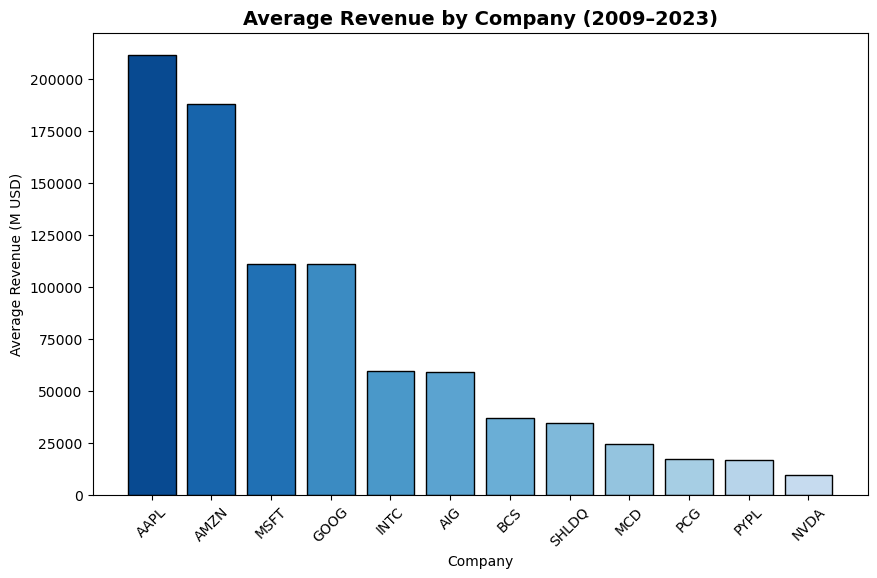

In [21]:
plt.figure(figsize=(10, 6))
revenue_by_company = df.groupby('Company')['Revenue'].mean().sort_values(ascending=False)
colors = plt.cm.Blues([0.9, 0.8, 0.75, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.25])
plt.bar(revenue_by_company.index, revenue_by_company.values, color=colors, edgecolor='black')
plt.title('Average Revenue by Company (2009–2023)', fontsize=14, fontweight='bold')
plt.xlabel('Company')
plt.ylabel('Average Revenue (M USD)')
plt.xticks(rotation=45)
plt.show()

#### Findings
AAPL and AMZN lead in average revenue. NVDA has the lowest average but has grown dramatically in recent years. High revenue does not always mean high profitability.

## 4. Bivariate Analysis
Exploring relationships between pairs of variables to uncover patterns and correlations.

### 4.1 Revenue vs Net Income by Sector
Analyzing whether higher revenue leads to higher profits across sectors.

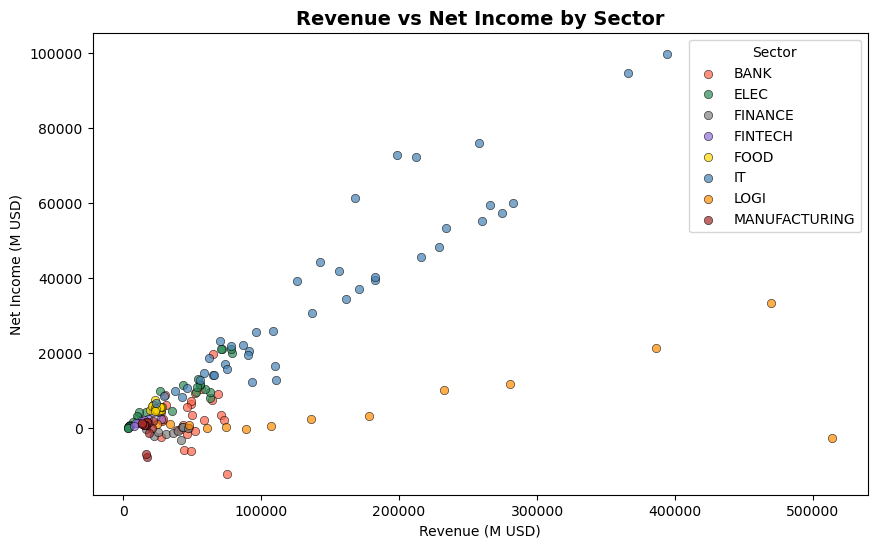

In [22]:
plt.figure(figsize=(10, 6))
colors = {'IT': 'steelblue', 'BANK': 'tomato', 'ELEC': 'seagreen',
          'FOOD': 'gold', 'FINTECH': 'mediumpurple', 'FINANCE': 'grey',
          'LOGI': 'darkorange', 'MANUFACTURING': 'brown'}

for sector, group in df.groupby('Category'):
    plt.scatter(group['Revenue'], group['Net Income'],
                label=sector, color=colors[sector], alpha=0.7, edgecolors='black', linewidths=0.5)

plt.title('Revenue vs Net Income by Sector', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (M USD)')
plt.ylabel('Net Income (M USD)')
plt.legend(title='Sector')
plt.show()

#### Findings
IT shows a strong positive correlation between revenue and net income. AMZN generates huge revenue but very little profit. Sector matters as much as company size.

### 4.2 Net Profit Margin Evolution by Company (2009–2023)
Tracking how profitability has changed over time for each company.

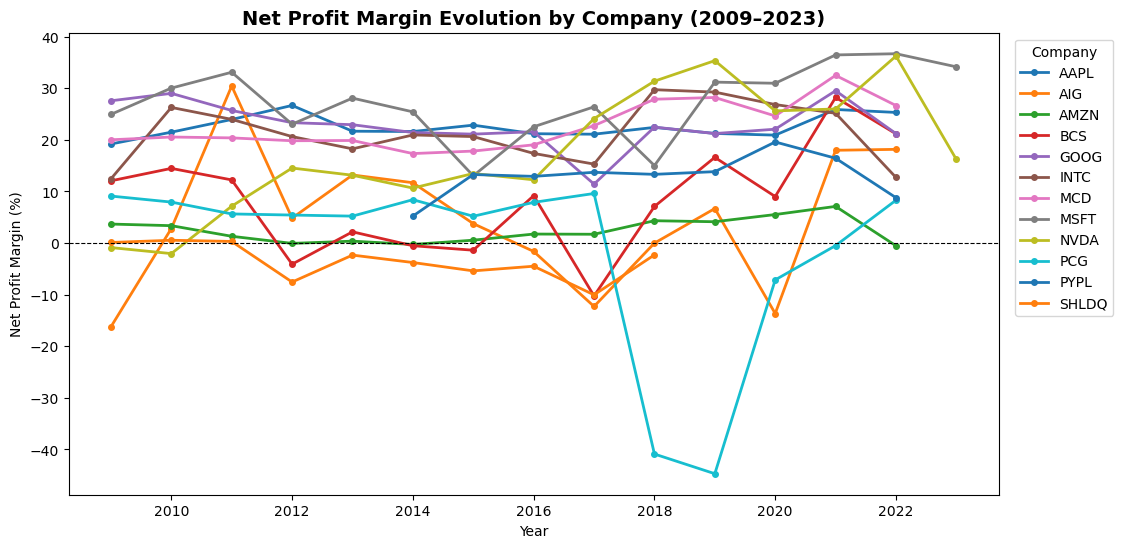

In [23]:
plt.figure(figsize=(12, 6))

for company, group in df.groupby('Company'):
    group_sorted = group.sort_values('Year')
    plt.plot(group_sorted['Year'], group_sorted['Net Profit Margin'],
             marker='o', label=company, linewidth=2, markersize=4)

plt.title('Net Profit Margin Evolution by Company (2009–2023)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Net Profit Margin (%)')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.legend(title='Company', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()

#### Findings
MSFT shows the most consistent growth, reaching 37% in 2023. NVDA explodes in 2022-2023 due to the AI boom. PCG drops to -44% during its bankruptcy period before recovering.

### 4.3 Inflation Rate vs Net Profit Margin
Investigating whether US inflation has impacted company profit margins.

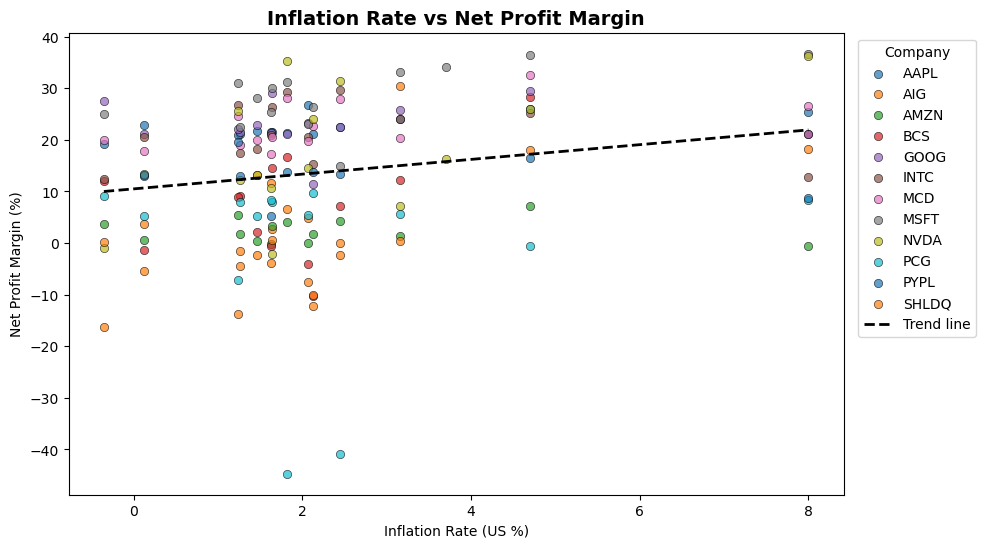

In [24]:
plt.figure(figsize=(10, 6))

for company, group in df.groupby('Company'):
    group_sorted = group.sort_values('Year')
    plt.scatter(group_sorted['Inflation Rate(in US)'], group_sorted['Net Profit Margin'],
                label=company, alpha=0.7, edgecolors='black', linewidths=0.5)

z = np.polyfit(df['Inflation Rate(in US)'], df['Net Profit Margin'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Inflation Rate(in US)'].min(), df['Inflation Rate(in US)'].max(), 100)
plt.plot(x_line, p(x_line), color='black', linestyle='--', linewidth=2, label='Trend line')

plt.title('Inflation Rate vs Net Profit Margin', fontsize=14, fontweight='bold')
plt.xlabel('Inflation Rate (US %)')
plt.ylabel('Net Profit Margin (%)')
plt.legend(title='Company', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()

#### Findings
No significant correlation between inflation and profit margins. The data is too scattered to draw conclusions. Company-specific factors outweigh macroeconomic conditions.

### 4.4 Number of Employees vs Revenue
Measuring revenue efficiency per employee across companies.

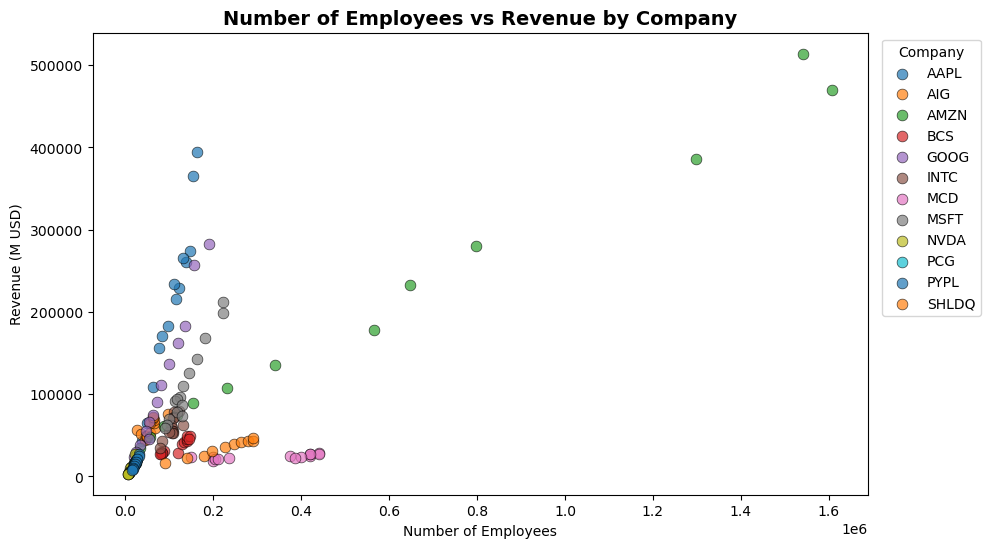

In [25]:
plt.figure(figsize=(10, 6))

for company, group in df.groupby('Company'):
    plt.scatter(group['Number of Employees'], group['Revenue'],
                label=company, alpha=0.7, edgecolors='black', linewidths=0.5, s=60)

plt.title('Number of Employees vs Revenue by Company', fontsize=14, fontweight='bold')
plt.xlabel('Number of Employees')
plt.ylabel('Revenue (M USD)')
plt.legend(title='Company', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()

#### Findings
AAPL generates the most revenue per employee, making it the most efficient company in the dataset. AMZN has the most employees but low revenue efficiency. Business model matters more than headcount.

## 5. SQL Upload
Loading the cleaned dataset into a SQLite database for SQL analysis.

In [29]:
conn = sqlite3.connect('financial_statements.db')

print(pd.read_sql("SELECT * FROM financials LIMIT 5", conn))
print("\nTotal filas:", pd.read_sql("SELECT COUNT(*) FROM financials", conn).values[0][0])
print("\nColumnas:", pd.read_sql("SELECT * FROM financials LIMIT 1", conn).columns.tolist())

conn.close()

conn = sqlite3.connect('financial_statements.db')
df.to_sql('financials', conn, if_exists='replace', index=False)
print("Dataset cargado correctamente en SQL")
conn.close()

   Year Company Category  Market Cap(in B USD)   Revenue  Gross Profit  \
0  2022    AAPL       IT               2066.94  394328.0      170782.0   
1  2021    AAPL       IT               2913.28  365817.0      152836.0   
2  2020    AAPL       IT               2255.97  274515.0      104956.0   
3  2019    AAPL       IT               1304.76  260174.0       98392.0   
4  2018    AAPL       IT                748.54  265595.0      101839.0   

   Net Income  Earning Per Share    EBITDA  Share Holder Equity  ...  \
0     99803.0               6.11  130541.0              50672.0  ...   
1     94680.0               5.61  120233.0              63090.0  ...   
2     57411.0               3.28   77344.0              65339.0  ...   
3     55256.0               2.97   76477.0              90488.0  ...   
4     59531.0               2.98   81801.0             107147.0  ...   

   Current Ratio  Debt/Equity Ratio       ROE      ROA      ROI  \
0         0.8794             2.3695  196.9589  28.2924 

## 6. SQL File Export
Exporting all 10 business questions as a commented .sql file for delivery.

In [31]:
queries = """
-- ============================================================
-- FINANCIAL STATEMENTS ANALYSIS (2009-2023)
-- EDA & SQL Bootcamp Project
-- ============================================================

-- P1: Which company has the highest average Net Profit Margin?
SELECT 
    Company,
    Category,
    ROUND(AVG("Net Profit Margin"), 2) AS avg_net_profit_margin
FROM financials
GROUP BY Company
ORDER BY avg_net_profit_margin DESC;

-- P2: How has EBITDA evolved for each company over time?
SELECT 
    Year,
    Company,
    ROUND(EBITDA, 2) AS ebitda
FROM financials
ORDER BY Company, Year;

-- P3: Which sector is most profitable measured by average ROE?
SELECT 
    Category,
    ROUND(AVG(ROE), 2) AS avg_roe,
    ROUND(AVG("Net Profit Margin"), 2) AS avg_net_profit_margin
FROM financials
GROUP BY Category
ORDER BY avg_roe DESC;

-- P4: Is there a correlation between Revenue and Net Income?
SELECT 
    Company,
    Category,
    ROUND(AVG(Revenue), 2) AS avg_revenue,
    ROUND(AVG("Net Income"), 2) AS avg_net_income,
    ROUND(AVG("Net Income") / AVG(Revenue) * 100, 2) AS efficiency_pct
FROM financials
GROUP BY Company
ORDER BY efficiency_pct DESC;

-- P5: Which company has the best ROA?
SELECT 
    Company,
    Category,
    ROUND(AVG(ROA), 2) AS avg_roa
FROM financials
GROUP BY Company
ORDER BY avg_roa DESC;

-- P6: Which company has grown the most in Market Cap?
SELECT 
    Company,
    ROUND(MIN("Market Cap(in B USD)"), 2) AS market_cap_start,
    ROUND(MAX("Market Cap(in B USD)"), 2) AS market_cap_end,
    ROUND(MAX("Market Cap(in B USD)") - MIN("Market Cap(in B USD)"), 2) AS absolute_growth,
    ROUND((MAX("Market Cap(in B USD)") - MIN("Market Cap(in B USD)")) 
          / MIN("Market Cap(in B USD)") * 100, 2) AS growth_pct
FROM financials
GROUP BY Company
ORDER BY growth_pct DESC;

-- P7: Has US inflation impacted Net Profit Margin over time?
SELECT 
    Year,
    ROUND(AVG("Inflation Rate(in US)"), 2) AS inflation_rate,
    ROUND(AVG("Net Profit Margin"), 2) AS avg_net_profit_margin
FROM financials
GROUP BY Year
ORDER BY Year;

-- P8: Which companies have a concerning Debt/Equity Ratio (> 2)?
SELECT 
    Company,
    Category,
    Year,
    ROUND("Debt/Equity Ratio", 2) AS debt_equity_ratio
FROM financials
WHERE "Debt/Equity Ratio" > 2
ORDER BY "Debt/Equity Ratio" DESC;

-- P9: Which company generates the most Operating Cash Flow 
--     relative to its Revenue?
SELECT 
    Company,
    Category,
    ROUND(AVG("Cash Flow from Operating"), 2) AS avg_operating_cf,
    ROUND(AVG(Revenue), 2) AS avg_revenue,
    ROUND(AVG("Cash Flow from Operating") / AVG(Revenue) * 100, 2) AS cf_to_revenue_pct
FROM financials
GROUP BY Company
ORDER BY cf_to_revenue_pct DESC;

-- P10: Is there a relationship between employees and Revenue?
SELECT 
    Company,
    Category,
    ROUND(AVG("Number of Employees"), 0) AS avg_employees,
    ROUND(AVG(Revenue), 2) AS avg_revenue,
    ROUND(AVG(Revenue) / AVG("Number of Employees"), 2) AS revenue_per_employee
FROM financials
GROUP BY Company
ORDER BY revenue_per_employee DESC;
"""

with open('financial_analysis.sql', 'w') as f:
    f.write(queries)

print("Archivo .sql creado correctamente")

Archivo .sql creado correctamente
